In [1]:
!pip install google-play-scraper pandas nltk scikit-learn matplotlib seaborn wordcloud


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Import Library

In [2]:
import pandas as pd  # untuk import dan olah data tabel
import numpy as np  # untuk bantu operasi data numerik
import re  # untuk membersihkan teks dengan regex
import string  # untuk bantu cleaning karakter
import nltk  # untuk tool preprocessing teks
import time  # untuk jeda saat scraping
import os  # untuk membuat folder penyimpanan hasil batch

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from wordcloud import WordCloud  # untuk membuat word cloud

import matplotlib.pyplot as plt
import seaborn as sns

from google_play_scraper import reviews, Sort

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/mariocristian/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/mariocristian/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Scraping Data Review Steam

In [4]:
# Simpan daftar negara ke CSV (jalankan sekali saja)
import pandas as pd

negara_dunia = [
    ('Amerika Serikat','en','us'), ('Kanada','en','ca'), ('Meksiko','es','mx'),
    ('Brasil','pt','br'), ('Argentina','es','ar'), ('Chile','es','cl'),
    ('Kolombia','es','co'), ('Peru','es','pe'), ('Venezuela','es','ve'),
    ('Ekuador','es','ec'), ('Bolivia','es','bo'), ('Paraguay','es','py'),
    ('Uruguay','es','uy'), ('Jamaika','en','jm'), ('Trinidad dan Tobago','en','tt'),
    ('Barbados','en','bb'), ('Bahama','en','bs'), ('Belize','en','bz'),
    ('Kosta Rika','es','cr'), ('Panama','es','pa'), ('Guatemala','es','gt'),
    ('Honduras','es','hn'), ('El Salvador','es','sv'), ('Nicaragua','es','ni'),
    ('Republik Dominika','es','do'), ('Haiti','fr','ht'), ('Kuba','es','cu'),
    ('Puerto Riko','es','pr'), ('Inggris','en','gb'), ('Irlandia','en','ie'),
    ('Prancis','fr','fr'), ('Jerman','de','de'), ('Italia','it','it'),
    ('Spanyol','es','es'), ('Portugal','pt','pt'), ('Belanda','nl','nl'),
    ('Belgia','fr','be'), ('Swiss','de','ch'), ('Austria','de','at'),
    ('Polandia','pl','pl'), ('Rusia','ru','ru'), ('Ukraina','uk','ua'),
    ('Turki','tr','tr'), ('Ceko','cs','cz'), ('Rumania','ro','ro'),
    ('Hungaria','hu','hu'), ('Yunani','el','gr'), ('Swedia','sv','se'),
    ('Norwegia','no','no'), ('Denmark','da','dk'), ('Finlandia','fi','fi'),
    ('Slovakia','sk','sk'), ('Slovenia','sl','si'), ('Bulgaria','bg','bg'),
    ('Serbia','sr','rs'), ('Kroasia','hr','hr'), ('Bosnia dan Herzegovina','bs','ba'),
    ('Makedonia Utara','mk','mk'), ('Albania','sq','al'), ('Montenegro','sr','me'),
    ('Latvia','lv','lv'), ('Lituania','lt','lt'), ('Estonia','et','ee'),
    ('Islandia','is','is'), ('Malta','mt','mt'), ('Luksemburg','fr','lu'),
    ('Belarus','be','by'), ('Moldova','ro','md'), ('Siprus','el','cy'),
    ('San Marino','it','sm'), ('Monako','fr','mc'), ('Liechtenstein','de','li'),
    ('Andorra','ca','ad'), ('Vatikan','it','va'), ('Jepang','ja','jp'),
    ('Korea Selatan','ko','kr'), ('China','zh','cn'), ('Taiwan','zh','tw'),
    ('Hong Kong','zh','hk'), ('Indonesia','id','id'), ('Malaysia','ms','my'),
    ('Thailand','th','th'), ('Vietnam','vi','vn'), ('Singapura','en','sg'),
    ('Filipina','tl','ph'), ('India','hi','in'), ('Pakistan','ur','pk'),
    ('Bangladesh','bn','bd'), ('Kamboja','km','kh'), ('Laos','lo','la'),
    ('Myanmar','my','mm'), ('Sri Lanka','si','lk'), ('Nepal','ne','np'),
    ('Kazakhstan','kk','kz'), ('Uzbekistan','uz','uz'), ('Kirgizstan','ky','kg'),
    ('Tajikistan','tg','tj'), ('Turkmenistan','tk','tm'), ('Azerbaijan','az','az'),
    ('Armenia','hy','am'), ('Georgia','ka','ge'), ('Mongolia','mn','mn'),
    ('Makau','zh','mo'), ('Brunei','ms','bn'), ('Timor-Leste','pt','tl'),
    ('Bhutan','dz','bt'), ('Maladewa','dv','mv'), ('Afghanistan','fa','af'),
    ('Arab Saudi','ar','sa'), ('Uni Emirat Arab','ar','ae'), ('Mesir','ar','eg'),
    ('Israel','he','il'), ('Iran','fa','ir'), ('Irak','ar','iq'),
    ('Yordania','ar','jo'), ('Lebanon','ar','lb'), ('Kuwait','ar','kw'),
    ('Qatar','ar','qa'), ('Oman','ar','om'), ('Bahrain','ar','bh'),
    ('Suriah','ar','sy'), ('Yaman','ar','ye'), ('Palestina','ar','ps'),
    ('Afrika Selatan','en','za'), ('Nigeria','en','ng'), ('Kenya','sw','ke'),
    ('Tanzania','sw','tz'), ('Ghana','en','gh'), ('Kamerun','fr','cm'),
    ('Senegal','fr','sn'), ('Pantai Gading','fr','ci'), ('Etiopia','am','et'),
    ('Uganda','sw','ug'), ('Mozambik','pt','mz'), ('Angola','pt','ao'),
    ('Zambia','en','zm'), ('Zimbabwe','en','zw'), ('Rwanda','fr','rw'),
    ('Botswana','en','bw'), ('Namibia','en','na'), ('Malawi','en','mw'),
    ('Mauritius','en','mu'), ('Tunisia','fr','tn'), ('Maroko','ar','ma'),
    ('Aljazair','ar','dz'), ('Libya','ar','ly'), ('Sudan','ar','sd'),
    ('Burkina Faso','fr','bf'), ('Mali','fr','ml'), ('Niger','fr','ne'),
    ('Togo','fr','tg'), ('Benin','fr','bj'), ('Gabon','fr','ga'),
    ('Republik Demokratik Kongo','fr','cd'), ('Republik Kongo','fr','cg'),
    ('Somalia','so','so'), ('Djibouti','fr','dj'), ('Eritrea','ti','er'),
    ('Madagaskar','fr','mg'), ('Komoro','ar','km'), ('Seychelles','fr','sc'),
    ('Tanjung Verde','pt','cv'), ('Guinea','fr','gn'), ('Guinea-Bissau','pt','gw'),
    ('Guinea Khatulistiwa','es','gq'), ('Sierra Leone','en','sl'), ('Liberia','en','lr'),
    ('Gambia','en','gm'), ('Sao Tome dan Principe','pt','st'), ('Afrika Tengah','fr','cf'),
    ('Chad','fr','td'), ('Sudan Selatan','en','ss'), ('Burundi','fr','bi'),
    ('Lesotho','en','ls'), ('Eswatini','en','sz'), ('Australia','en','au'),
    ('Selandia Baru','en','nz'), ('Papua Nugini','en','pg'), ('Fiji','en','fj'),
    ('Kepulauan Solomon','en','sb'), ('Vanuatu','fr','vu'), ('Samoa','en','ws'),
    ('Tonga','en','to'), ('Kiribati','en','ki'), ('Nauru','en','nr'),
    ('Tuvalu','en','tv'), ('Palau','en','pw'), ('Mikronesia','en','fm'),
    ('Kepulauan Marshall','en','mh'),
]

df_negara_dunia = pd.DataFrame(negara_dunia, columns=['negara', 'lang', 'country'])
df_negara_dunia.to_csv('daftar_negara.csv', index=False)
print(f"✅ Tersimpan: daftar_negara.csv ({len(df_negara_dunia)} negara)")

✅ Tersimpan: daftar_negara.csv (189 negara)


In [5]:
# ══════════════════════════════════════════════════════════
# REVISI 1 — Scraping ulang tanpa filter negara & bahasa
# ══════════════════════════════════════════════════════════
!pip install google-play-scraper langdetect -q

from google_play_scraper import reviews, Sort
from langdetect import detect, DetectorFactory
from concurrent.futures import ThreadPoolExecutor, as_completed
import pandas as pd
import time, warnings

warnings.filterwarnings('ignore')
DetectorFactory.seed = 0

APP_ID      = 'com.valvesoftware.android.steam.community'
MAX_RETRY   = 3
JEDA_RETRY  = 3    # ← dari 5 ke 3
JEDA_BATCH  = 0.1  # ← dari 0.3 ke 0.1
BATCH_SIZE  = 200
MAX_WORKERS = 10   # ← dari 6 ke 10

# ✅ Baca daftar negara dari file CSV
df_neg = pd.read_csv('daftar_negara.csv')
NEGARA_REVISI = list(df_neg.itertuples(index=False, name=None))
print(f"🌍 Total negara: {len(NEGARA_REVISI)}")

def detect_lang(text):
    try:
        lang = detect(str(text))
        return 'zh' if lang.startswith('zh') else lang
    except:
        return 'unknown'

def proses_negara_tanpa_filter(item):
    nama, lang, country = item
    hasil, token = [], None

    while True:
        for attempt in range(MAX_RETRY):
            try:
                data, token = reviews(APP_ID, lang=lang, country=country,
                                      sort=Sort.NEWEST, count=BATCH_SIZE,
                                      continuation_token=token)
                break
            except Exception as e:
                if attempt < MAX_RETRY - 1:
                    time.sleep(JEDA_RETRY * (attempt + 1))
                else:
                    data = []
                    break

        if not data:
            break

        hasil.extend(data)

        if token is None:
            break

        time.sleep(JEDA_BATCH)

    if not hasil:
        return {'negara': nama, 'total': 0, 'raw': []}

    df = pd.DataFrame(hasil)[['reviewId', 'content', 'score', 'at']].copy()
    df.columns = ['review_id', 'review', 'rating', 'date']
    df = df.dropna(subset=['review']).drop_duplicates(subset=['review_id'])
    df['bahasa'] = df['review'].apply(detect_lang)

    return {'negara': nama, 'total': len(df), 'raw': df.to_dict('records')}

print(f'\n🚀 Scraping {len(NEGARA_REVISI)} negara tanpa filter bahasa...\n')

data_revisi = [None] * len(NEGARA_REVISI)
idx_map_revisi = {item: i for i, item in enumerate(NEGARA_REVISI)}

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {executor.submit(proses_negara_tanpa_filter, item): item for item in NEGARA_REVISI}
    done = 0
    for future in as_completed(futures):
        item = futures[future]
        i = idx_map_revisi[item]
        result = future.result()
        data_revisi[i] = result
        done += 1
        print(f'[{done}/{len(NEGARA_REVISI)}] {result["negara"]:<30} total={result["total"]:>6,}')

print('\n✅ Scraping Revisi 1 selesai!')
print(f'📊 Total review terkumpul : {sum(r["total"] for r in data_revisi):,}')


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
🌍 Total negara: 189

🚀 Scraping 189 negara tanpa filter bahasa...

[1/189] Brasil                         total=22,266
[2/189] Chile                          total=27,884
[3/189] Kolombia                       total=27,884
[4/189] Peru                           total=27,884
[5/189] Venezuela                      total=27,884
[6/189] Meksiko                        total=27,884
[7/189] Ekuador                        total=27,884
[8/189] Argentina                      total=27,884
[9/189] Bolivia                        total=27,884
[10/189] Paraguay                       total=27,884
[11/189] Uruguay                        total=27,884
[12/189] Kosta Rika                     total=27,884
[13/189] Kanada                         total=81,470
[14/189] Amerika Serikat                total=81,470
[15/189] Panama                         total=27,885
[16/189] Guatemala                

In [6]:
# ══════════════════════════════════════════════════════════
# TAHAP 1 — Cleaning
# ══════════════════════════════════════════════════════════
import pandas as pd

all_records = []
for r in data_revisi:
    for rec in r['raw']:
        all_records.append({
            'negara'    : r['negara'],
            'review_id' : rec['review_id'],
            'review'    : rec['review'],
            'rating'    : rec['rating'],
            'date'      : rec['date'],
            'bahasa'    : rec.get('bahasa', 'unknown'),
        })

df = pd.DataFrame(all_records)
print(f"Total sebelum cleaning : {len(df):,}")

df = df.dropna(subset=['review'])
df = df[df['review'].str.strip() != '']
df = df.drop_duplicates(subset=['review_id'], keep='first')
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['date']   = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['rating', 'date'])
df['rating'] = df['rating'].astype(int)
df['review'] = df['review'].str.strip()

def label_sentiment(score):
    if score >= 4:   return 'positif'
    elif score == 3: return 'netral'
    else:            return 'negatif'

df['polarity'] = df['rating'].apply(label_sentiment)
df = df.reset_index(drop=True)

print(f"Total setelah cleaning : {len(df):,}")
print(f"\nDistribusi polarity:")
print(df['polarity'].value_counts())

df.to_csv('steam_reviews_clean.csv', index=False, encoding='utf-8')
print(f"\n✅ Tersimpan: steam_reviews_clean.csv")

Total sebelum cleaning : 4,828,155
Total setelah cleaning : 299,034

Distribusi polarity:
polarity
positif    137620
negatif    137441
netral      23973
Name: count, dtype: int64

✅ Tersimpan: steam_reviews_clean.csv


Total sebelum dedup: 4,828,155
Total setelah dedup : 299,034

🏆 10 Negara dengan Komentar Terbanyak:
  Rank   Negara                    Total Review
  ---------------------------------------------
  1      Amerika Serikat                 81,470
  2      Rusia                           70,608
  3      Meksiko                         27,884
  4      Brasil                          22,266
  5      Turki                           12,277
  6      Polandia                        12,142
  7      Jerman                          10,752
  8      Indonesia                        7,482
  9      Haiti                            6,208
  10     Korea Selatan                    5,848

  Total keseluruhan: 256,937


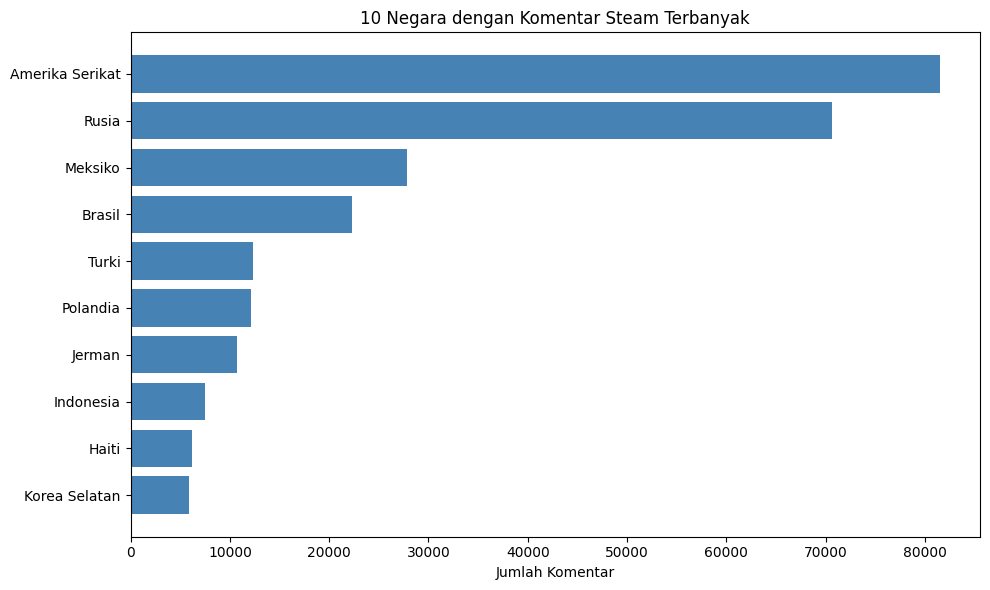

✅ Tersimpan: top10_negara.csv


In [7]:
# ══════════════════════════════════════════════════════════
# REVISI 2 — Sortir 10 negara dengan komentar terbanyak
# ══════════════════════════════════════════════════════════
import pandas as pd
import matplotlib.pyplot as plt

# Gabungkan semua raw data
all_records = []
for r in data_revisi:
    for rec in r['raw']:
        all_records.append({
            'negara'    : r['negara'],
            'review_id' : rec['review_id'],
            'review'    : rec['review'],
            'rating'    : rec['rating'],
            'date'      : rec['date'],
            'bahasa'    : rec.get('bahasa', 'unknown'),
        })

df_all_raw = pd.DataFrame(all_records)
print(f"Total sebelum dedup: {len(df_all_raw):,}")

# ✅ Dedup global — review yang sama hanya dihitung 1x
df_all_raw = df_all_raw.drop_duplicates(subset=['review_id'], keep='first')
print(f"Total setelah dedup : {len(df_all_raw):,}")

# Hitung per negara
df_per_negara = (
    df_all_raw.groupby('negara')
    .size()
    .reset_index(name='total_review')
    .sort_values('total_review', ascending=False)
    .reset_index(drop=True)
)

# Pastikan Indonesia masuk Top 10
top10_negara = df_per_negara.head(10).copy()
if 'Indonesia' not in top10_negara['negara'].values:
    indonesia_row = df_per_negara[df_per_negara['negara'] == 'Indonesia']
    top10_negara = pd.concat([top10_negara.head(9), indonesia_row], ignore_index=True)
    print("⚠️ Indonesia ditambahkan ke daftar")

top10_negara = top10_negara.reset_index(drop=True)
top10_negara.index += 1

print("\n🏆 10 Negara dengan Komentar Terbanyak:")
print("=" * 40)
print(f"  {'Rank':<6} {'Negara':<25} {'Total Review':>12}")
print(f"  {'-'*45}")
for rank, row in enumerate(top10_negara.itertuples(), 1):
    print(f"  {rank:<6} {row.negara:<25} {row.total_review:>12,}")

print(f"\n  Total keseluruhan: {top10_negara['total_review'].sum():,}")

# Visualisasi
plt.figure(figsize=(10, 6))
plt.barh(top10_negara['negara'][::-1], top10_negara['total_review'][::-1], color='steelblue')
plt.xlabel('Jumlah Komentar')
plt.title('10 Negara dengan Komentar Steam Terbanyak')
plt.tight_layout()
plt.show()

top10_negara.to_csv('top10_negara.csv', index=False, encoding='utf-8')
print("✅ Tersimpan: top10_negara.csv")

In [8]:
# ══════════════════════════════════════════════════════════
# REVISI 3 — Sortir bahasa terbanyak per negara (Top 10)
# ══════════════════════════════════════════════════════════

# Mapping kode bahasa ke nama lengkap   
NAMA_BAHASA = {
    'en': 'English',        'id': 'Indonesian',     'fr': 'French',
    'es': 'Spanish',        'de': 'German',         'pt': 'Portuguese',
    'ru': 'Russian',        'zh': 'Chinese',        'ja': 'Japanese',
    'ko': 'Korean',         'ar': 'Arabic',         'tr': 'Turkish',
    'it': 'Italian',        'nl': 'Dutch',          'pl': 'Polish',
    'vi': 'Vietnamese',     'th': 'Thai',           'uk': 'Ukrainian',
    'sv': 'Swedish',        'da': 'Danish',         'fi': 'Finnish',
    'no': 'Norwegian',      'cs': 'Czech',          'ro': 'Romanian',
    'hu': 'Hungarian',      'el': 'Greek',          'he': 'Hebrew',
    'fa': 'Persian',        'hi': 'Hindi',          'bn': 'Bengali',
    'ms': 'Malay',          'tl': 'Filipino',       'sk': 'Slovak',
    'bg': 'Bulgarian',      'hr': 'Croatian',       'sr': 'Serbian',
    'lt': 'Lithuanian',     'lv': 'Latvian',        'et': 'Estonian',
    'sl': 'Slovenian',      'sq': 'Albanian',       'mk': 'Macedonian',
    'bs': 'Bosnian',        'ca': 'Catalan',        'af': 'Afrikaans',
    'sw': 'Swahili',        'am': 'Amharic',        'so': 'Somali',
    'ur': 'Urdu',           'ne': 'Nepali',         'si': 'Sinhala',
    'km': 'Khmer',          'lo': 'Lao',            'my': 'Burmese',
    'ka': 'Georgian',       'hy': 'Armenian',       'az': 'Azerbaijani',
    'kk': 'Kazakh',         'uz': 'Uzbek',          'mn': 'Mongolian',
    'cy': 'Welsh',          'is': 'Icelandic',      'mt': 'Maltese',
    'be': 'Belarusian',     'gl': 'Galician',       'eu': 'Basque',
    'unknown': 'Unknown',
}

top10_list = top10_negara['negara'].tolist()

hasil_bahasa = []

for r in data_revisi:
    if r['negara'] not in top10_list:
        continue

    df_tmp = pd.DataFrame(r['raw'])
    if df_tmp.empty or 'bahasa' not in df_tmp.columns:
        continue

    dist_bahasa = (
        df_tmp['bahasa']
        .value_counts()
        .reset_index()
    )
    dist_bahasa.columns = ['bahasa', 'jumlah']

    # ✅ Ganti kode bahasa ke nama lengkap
    dist_bahasa['bahasa'] = dist_bahasa['bahasa'].map(
        lambda x: NAMA_BAHASA.get(x, x)
    )

    dist_bahasa['negara'] = r['negara']
    dist_bahasa['persentase'] = (dist_bahasa['jumlah'] / dist_bahasa['jumlah'].sum() * 100).round(1)
    hasil_bahasa.append(dist_bahasa)

# Tampilkan ranking bahasa per negara
print("🌐 Ranking Bahasa per Negara (Top 10 Negara):")
print("=" * 60)

for negara in top10_list:
    data_neg = pd.concat(hasil_bahasa)
    data_neg = data_neg[data_neg['negara'] == negara].sort_values('jumlah', ascending=False)
    total = data_neg['jumlah'].sum()
    print(f"\n📍 {negara} (total review: {total:,})")
    print(f"  {'Rank':<6} {'Bahasa':<15} {'Jumlah':>8} {'Persentase':>12}")
    print(f"  {'-'*43}")
    for rank, (_, row) in enumerate(data_neg.iterrows(), 1):
        print(f"  {rank:<6} {row['bahasa']:<15} {int(row['jumlah']):>8,} {row['persentase']:>10.1f}%")

# Simpan ke CSV
df_all = pd.concat(hasil_bahasa, ignore_index=True)
df_all = df_all.sort_values(['negara', 'jumlah'], ascending=[True, False])
df_all.to_csv('distribusi_bahasa_top10.csv', index=False, encoding='utf-8')
print("\n✅ Tersimpan: distribusi_bahasa_top10.csv")

🌐 Ranking Bahasa per Negara (Top 10 Negara):

📍 Amerika Serikat (total review: 81,470)
  Rank   Bahasa            Jumlah   Persentase
  -------------------------------------------
  1      English           67,782       83.2%
  2      Somali             1,809        2.2%
  3      Afrikaans          1,324        1.6%
  4      Romanian             940        1.2%
  5      German               805        1.0%
  6      Italian              701        0.9%
  7      Dutch                671        0.8%
  8      Filipino             594        0.7%
  9      French               570        0.7%
  10     Norwegian            546        0.7%
  11     Indonesian           473        0.6%
  12     Danish               440        0.5%
  13     Catalan              391        0.5%
  14     Polish               389        0.5%
  15     Unknown              380        0.5%
  16     Welsh                369        0.5%
  17     Slovenian            366        0.4%
  18     Estonian             361     

In [9]:
import pandas as pd

# Baca file distribusi bahasa top 10
df_bahasa = pd.read_csv('distribusi_bahasa_top10.csv')

# Ambil 3 bahasa tertinggi per negara
top3_bahasa = (
    df_bahasa.sort_values(['negara', 'jumlah'], ascending=[True, False])
    .groupby('negara')
    .head(3)
    .reset_index(drop=True)
)

print("📊 3 Bahasa Tertinggi per Negara (10 Negara):")
print("=" * 60)
for negara in top3_bahasa['negara'].unique():
    data = top3_bahasa[top3_bahasa['negara'] == negara]
    print(f"\n📍 {negara}")
    for rank, (_, row) in enumerate(data.iterrows(), 1):
        print(f"  {rank}. {row['bahasa']:<15} {row['jumlah']:>6,} ({row['persentase']}%)")

top3_bahasa.to_csv('top3_bahasa_per_negara.csv', index=False, encoding='utf-8')
print("\n✅ Tersimpan: top3_bahasa_per_negara.csv")
print(f"Total analisis: {len(top3_bahasa)} (10 negara × 3 bahasa)")

📊 3 Bahasa Tertinggi per Negara (10 Negara):

📍 Amerika Serikat
  1. English         67,782 (83.2%)
  2. Somali           1,809 (2.2%)
  3. Afrikaans        1,324 (1.6%)

📍 Brasil
  1. Portuguese      17,039 (76.5%)
  2. English          1,185 (5.3%)
  3. Italian            635 (2.9%)

📍 Haiti
  1. French           4,659 (75.0%)
  2. English            648 (10.4%)
  3. Romanian            94 (1.5%)

📍 Indonesia
  1. Indonesian       3,814 (51.0%)
  2. English          1,319 (17.6%)
  3. Filipino           544 (7.3%)

📍 Jerman
  1. German           8,718 (81.1%)
  2. English          1,089 (10.1%)
  3. Romanian            88 (0.8%)

📍 Korea Selatan
  1. Korean           5,399 (92.3%)
  2. English            242 (4.1%)
  3. Somali              58 (1.0%)

📍 Meksiko
  1. Spanish         21,637 (77.6%)
  2. English            983 (3.5%)
  3. Portuguese         740 (2.7%)

📍 Polandia
  1. Polish           8,476 (69.8%)
  2. English          1,057 (8.7%)
  3. Slovenian          373 (3.1%)

📍 

Cleaning Data

In [9]:
import pandas as pd

# load langsung dari file yang sudah ada
df = pd.read_csv('steam_reviews_clean.csv')

print(f"Total data: {len(df):,}")
print(f"Kolom: {df.columns.tolist()}")
df.head()

Total data: 298,946
Kolom: ['negara', 'review_id', 'review', 'rating', 'date', 'bahasa', 'polarity']


,negara,review_id,review,rating,date,bahasa,polarity
0,Amerika Serikat,714b1771-34e1-453c-ae6b-9d3a52285850,"""Affordable Console and Controller"". Then maki...",1,2026-07-10 22:30:03,en,negatif
1,Amerika Serikat,4de69bd3-0683-4fbf-8704-23fe20f720f0,"Overall, it's pretty good. My main complaint i...",4,2026-07-10 22:28:29,en,positif
2,Amerika Serikat,a0968a88-a3ec-4cc9-8057-2371926646da,in this aap my steam account library is not sh...,3,2026-07-10 21:19:41,en,netral
3,Amerika Serikat,dabdb995-86ab-46b4-801f-c8eec3e0d44d,I have steam on my laptop and I keep getting a...,1,2026-07-10 20:30:26,en,negatif
4,Amerika Serikat,062dfcca-b034-45f5-a5a9-659795701cd4,i scan to login in steam desktop and this app ...,1,2026-07-10 20:20:49,en,negatif


Preprocessing

In [10]:
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

stop_words = set(stopwords.words('english')) | set(stopwords.words('indonesian'))

# fungsi bersihkan teks
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)   # hapus URL
    text = re.sub(r'[^a-zA-Z\s]', '', text)       # hapus angka & simbol
    text = re.sub(r'\s+', ' ', text).strip()       # hapus spasi berlebih
    return text

# fungsi tokenisasi
def tokenize_text(text):
    return word_tokenize(str(text))

# fungsi hapus stopwords
def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words]

# fungsi gabung token kembali jadi kalimat
def to_sentence(tokens):
    return ' '.join(tokens)

print('✅ Fungsi preprocessing siap')

df['text_clean']    = df['review'].apply(clean_text)
df['text_token']    = df['text_clean'].apply(tokenize_text)
df['text_stopword'] = df['text_token'].apply(remove_stopwords)
df['text_final']    = df['text_stopword'].apply(to_sentence)

# ✅ Buat kolom polarity dulu sebelum dipanggil
def label_sentiment(score):
    if score >= 4:
        return 'positif'
    elif score == 3:
        return 'netral'
    else:  # score 1 atau 2
        return 'negatif'

df['polarity'] = df['rating'].apply(label_sentiment)

print("Distribusi polarity:")
print(df['polarity'].value_counts())
print(df['polarity'].value_counts(normalize=True).mul(100).round(1))

✅ Fungsi preprocessing siap
Distribusi polarity:
polarity
positif    137587
negatif    137388
netral      23971
Name: count, dtype: int64
polarity
positif    46.0
negatif    46.0
netral      8.0
Name: proportion, dtype: float64


Klasifikasi Sentimen Awal Berdasarkan Rating Ulasan

In [11]:
def label_sentiment(score):
    if score >= 4:   return 'positive'
    elif score == 3: return 'neutral'
    else:            return 'negative'

df['rating_bintang'] = df['rating'].apply(
    lambda x: '⭐' * int(x) if pd.notnull(x) and 1 <= int(x) <= 5 else ''
)

print("Distribusi polarity:")
print(df['polarity'].value_counts())
print(f"\nTotal: {df['polarity'].value_counts().sum():,}")
df[['review', 'rating', 'rating_bintang', 'polarity']].head()

Distribusi polarity:
polarity
positif    137587
negatif    137388
netral      23971
Name: count, dtype: int64

Total: 298,946


,review,rating,rating_bintang,polarity
0,"""Affordable Console and Controller"". Then maki...",1,⭐,negatif
1,"Overall, it's pretty good. My main complaint i...",4,⭐⭐⭐⭐,positif
2,in this aap my steam account library is not sh...,3,⭐⭐⭐,netral
3,I have steam on my laptop and I keep getting a...,1,⭐,negatif
4,i scan to login in steam desktop and this app ...,1,⭐,negatif


Fungsi Pelabelan Sentimen Berdasarkan Rating Ulasan

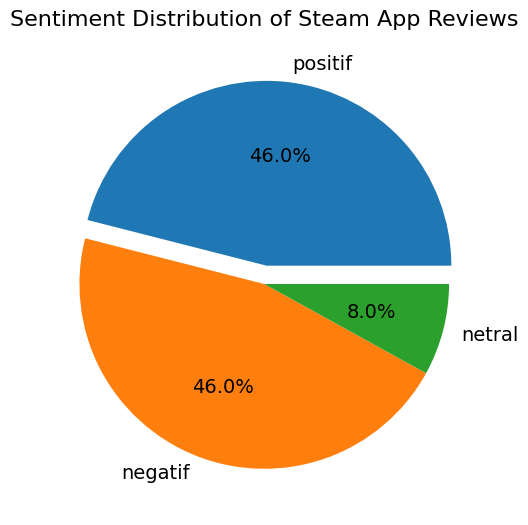

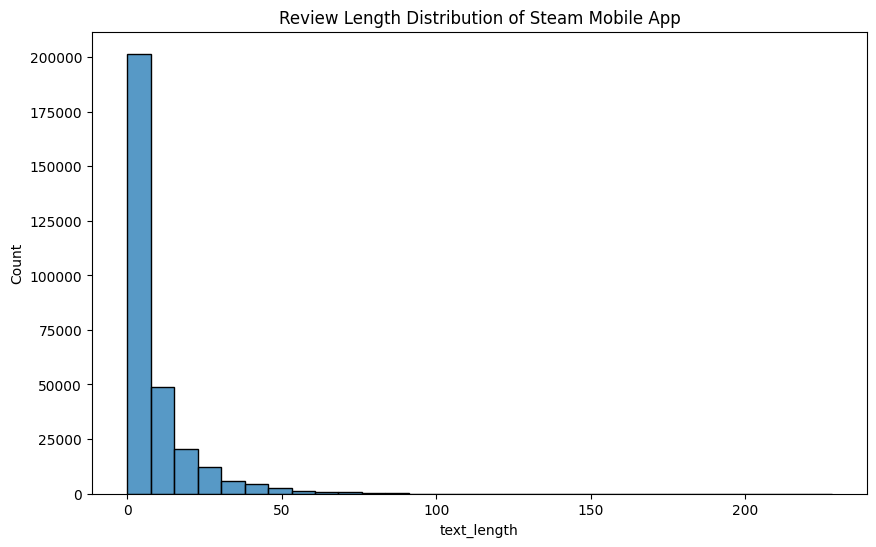

In [12]:
# Visualisasi distribusi sentimen
plt.figure(figsize=(6, 6))

sizes = [count for count in df['polarity'].value_counts()]
labels = list(df['polarity'].value_counts().index)

if len(labels) == 3:
    explode = (0.1, 0, 0)
elif len(labels) == 2:
    explode = (0.1, 0)
else:
    explode = None

plt.pie(
    x=sizes,
    labels=labels,
    autopct='%1.1f%%',
    explode=explode,
    textprops={'fontsize': 14}
)

plt.title('Sentiment Distribution of Steam App Reviews', fontsize=16, pad=20)
plt.show()

# Menghitung panjang teks review
df['text_length'] = df['text_final'].apply(lambda x: len(x.split()))

# Visualisasi distribusi panjang review
plt.figure(figsize=(10, 6))
sns.histplot(df['text_length'], bins=30)

plt.title('Review Length Distribution of Steam Mobile App')
plt.xlabel('text_length')
plt.ylabel('Count')
plt.show()

Deteksi Anomali

In [13]:
# bersihkan NaN di kolom review dan rating sebelum proses
df['review'] = df['review'].fillna('').astype(str)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce').fillna(0).astype(int)

# pastikan kolom text_final juga ada (dari preprocessing sebelumnya)
if 'text_final' not in df.columns:
    df['text_final'] = df['review']

# Menghitung panjang review asli
df['review_length'] = df['review'].apply(lambda x: len(x.split()))

# Fungsi untuk mendeteksi karakter berulang berlebihan
def has_repeated_chars(text):
    text = str(text).lower()
    return 1 if re.search(r'(.)\1{3,}', text) else 0

# Daftar frasa generik
generic_phrases = {
    'good app', 'nice app', 'bad app', 'love it', 'worst app',
    'very good', 'very bad', 'so good', 'so bad', 'great app'
}

def has_generic_phrase(text):
    text = str(text).lower().strip()
    return 1 if text in generic_phrases else 0

def is_extreme_rating(score):
    return 1 if score in [1, 5] else 0

df['has_repeated_chars'] = df['review'].apply(has_repeated_chars)
df['has_generic_phrase'] = df['review'].apply(has_generic_phrase)
df['is_extreme_rating']  = df['rating'].apply(is_extreme_rating)
df['is_short_review']    = df['review_length'].apply(lambda x: 1 if x <= 3 else 0)

positive_words = {'good', 'great', 'love', 'best', 'nice', 'amazing', 'helpful', 'easy'}
negative_words = {'bad', 'worst', 'hate', 'bug', 'error', 'problem', 'slow', 'broken'}

def detect_text_rating_mismatch(row):
    text     = str(row['text_final']).lower().split()
    rating   = row['rating']
    pos_count = sum(1 for word in text if word in positive_words)
    neg_count = sum(1 for word in text if word in negative_words)
    if rating >= 4 and neg_count > pos_count:
        return 'anomali'
    elif rating <= 2 and pos_count > neg_count:
        return 'anomali'
    elif rating == 3:
        return 'perlu_tinjauan'
    else:
        return 'normal'

df['anomaly_status'] = df.apply(detect_text_rating_mismatch, axis=1)

def detect_buzzer(row):
    score = 0
    if row['anomaly_status']  == 'anomali': score += 1
    if row['is_short_review'] == 1:         score += 1
    if row['has_generic_phrase'] == 1:      score += 1
    if row['has_repeated_chars'] == 1:      score += 1
    if row['is_extreme_rating'] == 1:       score += 1
    return 'buzzer' if score >= 3 else 'non_buzzer'

df['buzzer_status'] = df.apply(detect_buzzer, axis=1)

print(df[['review','rating','polarity','review_length',
          'has_repeated_chars','has_generic_phrase',
          'is_extreme_rating','anomaly_status','buzzer_status']].head(10))

print("\nDistribusi anomali:")
print(df['anomaly_status'].value_counts())
print("\nDistribusi buzzer:")
print(df['buzzer_status'].value_counts())

                                              review  rating polarity  \
0  "Affordable Console and Controller". Then maki...       1  negatif   
1  Overall, it's pretty good. My main complaint i...       4  positif   
2  in this aap my steam account library is not sh...       3   netral   
3  I have steam on my laptop and I keep getting a...       1  negatif   
4  i scan to login in steam desktop and this app ...       1  negatif   
5  App loading speed is too much slow and everyti...       1  negatif   
6  refuses to work when it feels like it. won't o...       1  negatif   
7  Extremely often every time I start the app, I ...       1  negatif   
8  the app keeps crashing when I'm trying to give...       1  negatif   
9  OMG! I didn't know it was available on the Goo...       4  positif   

   review_length  has_repeated_chars  has_generic_phrase  is_extreme_rating  \
0             13                   0                   0                  1   
1             73                   0  

In [14]:
rating_buzzer_table = pd.DataFrame({
    'rating_bintang': ['⭐', '⭐⭐', '⭐⭐⭐', '⭐⭐⭐⭐', '⭐⭐⭐⭐⭐'],
    'rating_angka': [1, 2, 3, 4, 5],
    'jumlah_review': [
        (df['rating'] == 1).sum(),
        (df['rating'] == 2).sum(),
        (df['rating'] == 3).sum(),
        (df['rating'] == 4).sum(),
        (df['rating'] == 5).sum()
    ],
    'jumlah_buzzer': [
        ((df['rating'] == 1) & (df['buzzer_status'] == 'buzzer')).sum(),
        ((df['rating'] == 2) & (df['buzzer_status'] == 'buzzer')).sum(),
        ((df['rating'] == 3) & (df['buzzer_status'] == 'buzzer')).sum(),
        ((df['rating'] == 4) & (df['buzzer_status'] == 'buzzer')).sum(),
        ((df['rating'] == 5) & (df['buzzer_status'] == 'buzzer')).sum()
    ],
    'jumlah_non_buzzer': [
        ((df['rating'] == 1) & (df['buzzer_status'] == 'non_buzzer')).sum(),
        ((df['rating'] == 2) & (df['buzzer_status'] == 'non_buzzer')).sum(),
        ((df['rating'] == 3) & (df['buzzer_status'] == 'non_buzzer')).sum(),
        ((df['rating'] == 4) & (df['buzzer_status'] == 'non_buzzer')).sum(),
        ((df['rating'] == 5) & (df['buzzer_status'] == 'non_buzzer')).sum()
    ]
})

rating_buzzer_table

,rating_bintang,rating_angka,jumlah_review,jumlah_buzzer,jumlah_non_buzzer
0,⭐,1,117910,1032,116878
1,⭐⭐,2,19478,1,19477
2,⭐⭐⭐,3,23971,0,23971
3,⭐⭐⭐⭐,4,26844,0,26844
4,⭐⭐⭐⭐⭐,5,110743,3119,107624


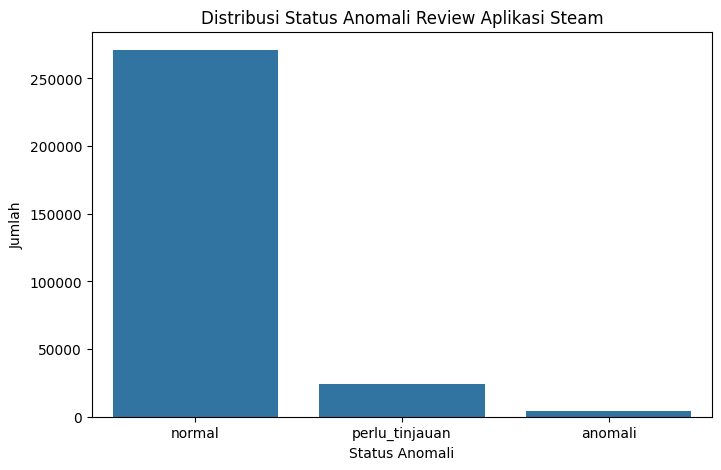

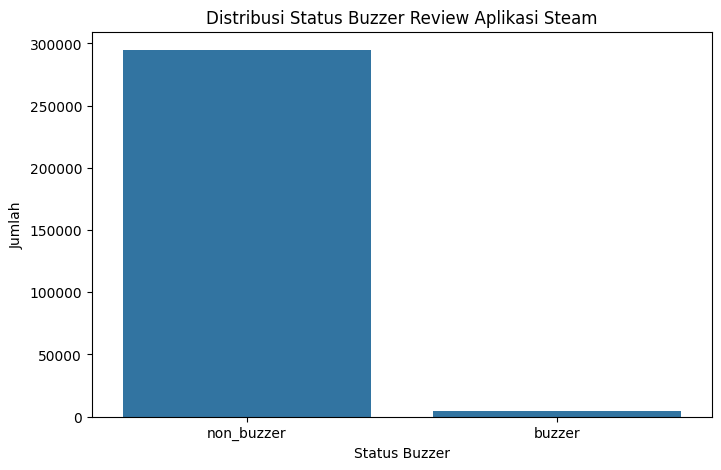

In [15]:
# Visualisasi distribusi status anomali
plt.figure(figsize=(8, 5))
sns.countplot(x='anomaly_status', data=df)
plt.title('Distribusi Status Anomali Review Aplikasi Steam')
plt.xlabel('Status Anomali')
plt.ylabel('Jumlah')
plt.show()

# Visualisasi distribusi status buzzer
plt.figure(figsize=(8, 5))
sns.countplot(x='buzzer_status', data=df)
plt.title('Distribusi Status Buzzer Review Aplikasi Steam')
plt.xlabel('Status Buzzer')
plt.ylabel('Jumlah')
plt.show()

Distribusi Konsistensi Review Steam

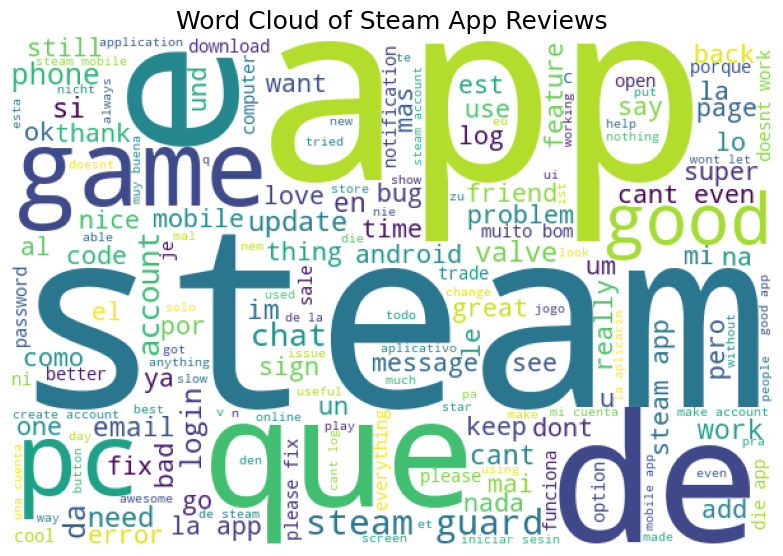

In [16]:
# Word cloud untuk seluruh review dengan sampel agar lebih ringan
sample_df = df.sample(n=20000, random_state=42) if len(df) > 20000 else df.copy()

list_words = ''
for review in sample_df['text_stopword']:
    for word in review:
        list_words += ' ' + word

wordcloud = WordCloud(
    width=600,
    height=400,
    background_color='white',
    min_font_size=10
).generate(list_words)

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Word Cloud of Steam App Reviews', fontsize=18)
ax.grid(False)
ax.imshow(wordcloud)
fig.tight_layout(pad=0)
ax.axis('off')
plt.show()

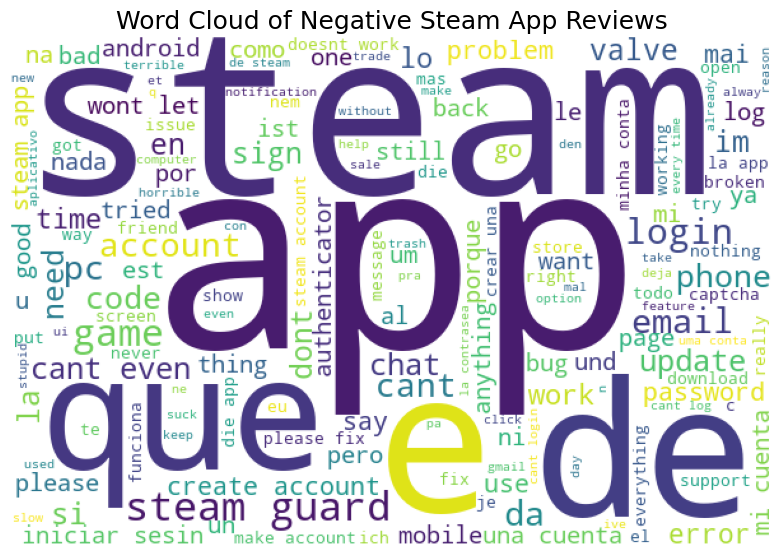

In [17]:
# Word cloud untuk review negatif dengan sampel agar lebih ringan
negative_reviews = df[df['polarity'] == 'negatif']
sample_negative = negative_reviews.sample(n=15000, random_state=42) if len(negative_reviews) > 15000 else negative_reviews.copy()

list_words = ''
for review in sample_negative['text_stopword']:
    for word in review:
        list_words += ' ' + word

wordcloud = WordCloud(
    width=600,
    height=400,
    background_color='white',
    min_font_size=10
).generate(list_words)

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Word Cloud of Negative Steam App Reviews', fontsize=18)
ax.grid(False)
ax.imshow(wordcloud)
fig.tight_layout(pad=0)
ax.axis('off')
plt.show()

In [18]:
anomali_df = df[df['anomaly_status'] == 'anomali'][[
    'review',
    'rating',
    'polarity',
    'review_length',
    'has_repeated_chars',
    'has_generic_phrase',
    'is_extreme_rating',
    'anomaly_status'
]]

print("Jumlah review anomali:", anomali_df.shape[0])
anomali_df.head(20)

Jumlah review anomali: 3858


,review,rating,polarity,review_length,has_repeated_chars,has_generic_phrase,is_extreme_rating,anomaly_status
13,recently the app is not working properly. it w...,1,negatif,19,0,0,1,anomali
47,won't refund a game that literally doesnt work...,1,negatif,30,0,0,1,anomali
50,The app used to be good before. it has been mo...,1,negatif,84,0,0,1,anomali
51,great. now i cant buy itemst for a month. app ...,1,negatif,13,0,0,1,anomali
60,It's slow,5,positif,2,0,0,1,anomali
66,it's amazing but it takes money for games,2,negatif,8,0,0,0,anomali
74,why this app is slow to load? Is there anyone ...,4,positif,13,0,0,0,anomali
164,"Good platform for buying games, but the suppor...",1,negatif,47,0,0,1,anomali
196,This app is so frustrating. Only 6 of my many ...,2,negatif,96,0,0,0,anomali
234,this is not a good app on mobile or pc. my acc...,1,negatif,21,0,0,1,anomali


In [19]:
buzzer_df = df[df['buzzer_status'] == 'buzzer'][[
    'review',
    'rating',
    'polarity',
    'review_length',
    'has_repeated_chars',
    'has_generic_phrase',
    'is_extreme_rating',
    'anomaly_status',
    'buzzer_status'
]]

print("Jumlah review terindikasi buzzer:", buzzer_df.shape[0])
buzzer_df.head(20)

Jumlah review terindikasi buzzer: 4152


,review,rating,polarity,review_length,has_repeated_chars,has_generic_phrase,is_extreme_rating,anomaly_status,buzzer_status
60,It's slow,5,positif,2,0,0,1,anomali,buzzer
69,great app,5,positif,2,0,1,1,normal,buzzer
100,worst app,1,negatif,2,0,1,1,normal,buzzer
509,not bad,5,positif,2,0,0,1,anomali,buzzer
536,nice app,5,positif,2,0,1,1,normal,buzzer
542,not good,1,negatif,2,0,0,1,anomali,buzzer
627,good app 👍👍👍👍👍😁😁😁😁😁,5,positif,3,1,0,1,normal,buzzer
634,very good,5,positif,2,0,1,1,normal,buzzer
712,so good,5,positif,2,0,1,1,normal,buzzer
767,worst app,1,negatif,2,0,1,1,normal,buzzer


TF - IDF

In [20]:
# Filter hanya review bahasa Inggris dan Indonesia yang punya text_final
df_model = df[
    (df['text_final'].str.strip() != '') &
    (df['bahasa'].isin(['en', 'id']))
].reset_index(drop=True)

print(f"Data untuk model: {len(df_model):,}")
print("Distribusi polarity data model:")
print(df_model['polarity'].value_counts())

X = df_model['text_final']
y = df_model['polarity']

tfidf   = TfidfVectorizer(max_features=20000, min_df=1, max_df=0.9, ngram_range=(1,3), sublinear_tf=True)
X_tfidf = tfidf.fit_transform(X)
print("\nBentuk TF-IDF:", X_tfidf.shape)

Data untuk model: 89,525
Distribusi polarity data model:
polarity
negatif    45189
positif    35493
netral      8843
Name: count, dtype: int64

Bentuk TF-IDF: (89525, 20000)


In [21]:
from sklearn.utils import resample

df_neg = df_model[df_model['polarity'] == 'negatif']   # ← ganti
df_pos = df_model[df_model['polarity'] == 'positif']   # ← ganti
df_neu = df_model[df_model['polarity'] == 'netral']    # ← ganti

target = min(len(df_neg), len(df_pos)) // 2
target = max(target, len(df_neu) * 2)

# Pastikan target tidak melebihi jumlah data yang tersedia
target_neg = min(target, len(df_neg))
target_pos = min(target, len(df_pos))

df_neg_bal = resample(df_neg, replace=False, n_samples=target_neg, random_state=42)
df_pos_bal = resample(df_pos, replace=False, n_samples=target_pos, random_state=42)
df_neu_bal = resample(df_neu, replace=True,  n_samples=target,     random_state=42)

df_bal = pd.concat([df_neg_bal, df_pos_bal, df_neu_bal]).reset_index(drop=True)
df_bal = df_bal.sample(frac=1, random_state=42).reset_index(drop=True)

print("Distribusi setelah balancing:")
print(df_bal['polarity'].value_counts())
print(f"Total data balanced: {len(df_bal):,}")

X = df_bal['text_final']
y = df_bal['polarity']

tfidf   = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.9, ngram_range=(1,2), sublinear_tf=True)
X_tfidf = tfidf.fit_transform(X)
print("\nBentuk TF-IDF:", X_tfidf.shape)

Distribusi setelah balancing:
polarity
positif    17746
negatif    17746
netral     17746
Name: count, dtype: int64
Total data balanced: 53,238

Bentuk TF-IDF: (53238, 5000)


Split data

In [22]:
# Membagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

# Menampilkan ukuran data latih dan data uji
print("Data latih:", X_train.shape)
print("Data uji:", X_test.shape)

Data latih: (42590, 5000)
Data uji: (10648, 5000)


Model Naive Bayes (MultinomialNB)

In [23]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.calibration import CalibratedClassifierCV

model_nb  = MultinomialNB(alpha=0.5)  # naikkan dari 0.1 ke 0.5
model_cal = CalibratedClassifierCV(model_nb, cv=3)
model_cal.fit(X_train, y_train)
y_pred = model_cal.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.689519158527423

Classification Report:

              precision    recall  f1-score   support

     negatif       0.70      0.72      0.71      3549
      netral       0.62      0.62      0.62      3549
     positif       0.75      0.73      0.74      3550

    accuracy                           0.69     10648
   macro avg       0.69      0.69      0.69     10648
weighted avg       0.69      0.69      0.69     10648



Confusion Matrix

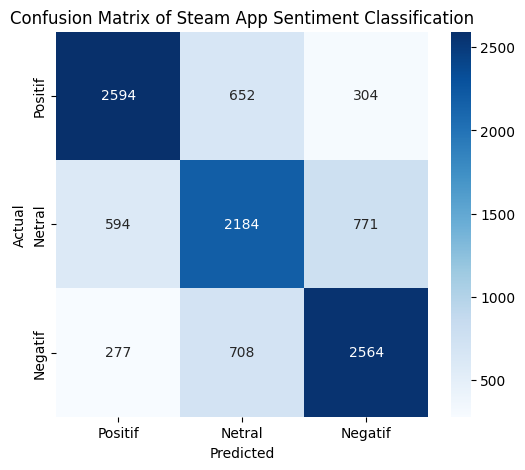

In [24]:
# Membuat confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=['positif', 'netral', 'negatif'])

# Menampilkan confusion matrix dalam bentuk heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Positif', 'Netral', 'Negatif'],
    yticklabels=['Positif', 'Netral', 'Negatif'],
    cmap='Blues'
)

plt.title('Confusion Matrix of Steam App Sentiment Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

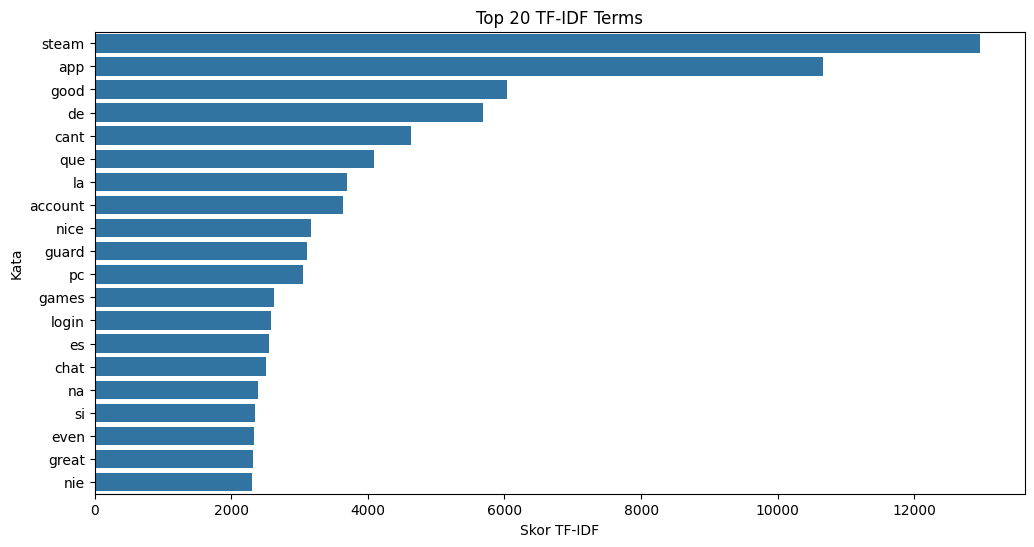

In [25]:
# Menampilkan 20 kata dengan skor TF-IDF tertinggi tanpa mengubah seluruh matrix ke array penuh
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Membatasi jumlah fitur agar lebih ringan
vectorizer = TfidfVectorizer(max_features=500, min_df=2, max_df=0.8)
X = vectorizer.fit_transform(df['text_final'])

# Menjumlahkan skor TF-IDF tiap kata
word_scores = X.sum(axis=0).A1
words = vectorizer.get_feature_names_out()

# Membuat dataframe kata dan total skor
tfidf_df = pd.DataFrame({
    'word': words,
    'jumlah': word_scores
})

# Mengambil 20 kata teratas
tfidf_df = tfidf_df.sort_values('jumlah', ascending=False).head(20)

# Membuat grafik
sns.barplot(x='jumlah', y='word', data=tfidf_df)
plt.title('Top 20 TF-IDF Terms')
plt.xlabel('Skor TF-IDF')
plt.ylabel('Kata')
plt.show()

In [26]:
# Menyesuaikan nama kolom agar cocok dengan aplikasi Streamlit
df_streamlit = df[['review', 'rating']].copy()
df_streamlit.columns = ['content', 'recommended']

# Mengubah rating menjadi label rekomendasi True/False
df_streamlit['recommended'] = df_streamlit['recommended'].apply(lambda x: True if x >= 4 else False)

# Menyimpan file CSV untuk Streamlit
df_streamlit.to_csv("steam_streamlit.csv", index=False, encoding="utf-8")

print(df_streamlit.head())

                                             content  recommended
0  "Affordable Console and Controller". Then maki...        False
1  Overall, it's pretty good. My main complaint i...         True
2  in this aap my steam account library is not sh...        False
3  I have steam on my laptop and I keep getting a...        False
4  i scan to login in steam desktop and this app ...        False


untuk menyimpan dataset kedalam streamlit

In [27]:
positive_words = {
    "good", "great", "love", "best", "nice", "amazing", "helpful", "easy",
    "awesome", "excellent", "fantastic", "perfect", "wonderful", "super",
    "recommended", "recommend", "satisfied", "smooth", "fast", "stable",
    "cool", "beautiful", "useful", "friendly", "impressive", "outstanding",
    "bagus", "baik", "mantap", "keren", "suka", "memuaskan", "hebat",
    "cepat", "lancar", "stabil", "berguna", "membantu", "mudah",
    "nyaman", "cocok", "terbaik", "istimewa", "praktis",
    "rapi", "oke", "ok", "aman", "senang", "puas", "top", "jos",
    "sip", "favorit", "berhasil", "bermanfaat"
}

negative_words = {
    "bad", "worst", "hate", "bug", "error", "problem", "slow", "broken",
    "awful", "terrible", "horrible", "useless", "disappointed", "annoying",
    "lag", "laggy", "crash", "failed", "failure", "hard", "difficult",
    "confusing", "scam", "fake", "waste", "poor", "unstable", "freeze",
    "jelek", "buruk", "parah", "kecewa", "rusak", "gagal", "lemot",
    "lambat", "eror", "susah", "sulit", "ribet", "membingungkan",
    "mengecewakan", "sampah", "payah", "bohong", "penipu",
    "tidak berguna", "gangguan", "bermasalah", "ngelag", "gak jelas",
    "tidak bagus", "ga bagus", "tidak suka", "benci", "kesal", "marah",
    "fatal", "drop", "hancur", "trash", "garbage",
    "anjing", "babi", "monyet", "bangsat", "kampret",
    "asu", "goblok", "tolol", "idiot", "dungu", "bebal",
    "tai", "sialan", "brengsek", "setan", "laknat",
    "dog", "pig", "monkey", "donkey", "stupid", "dumb"
}

neutral_words = {
    "okay", "ok", "average", "normal", "standard", "biasa", "lumayan",
    "cukup", "sedang", "so so", "b aja", "biasa saja",
    "standar", "netral", "medium", "common", "fine", "moderate"
}

def sentiment_from_text(text):
    text = str(text).lower()
    words = text.split()
    pos_count = sum(1 for word in words if word in positive_words)
    neg_count = sum(1 for word in words if word in negative_words)
    neu_count = sum(1 for word in words if word in neutral_words)
    if pos_count > neg_count and pos_count >= neu_count:
        return 'positif'
    elif neg_count > pos_count and neg_count >= neu_count:
        return 'negatif'
    else:
        return 'netral'

df['sentiment_text'] = df['review'].apply(sentiment_from_text)

print("Distribusi sentiment_text:")
print(df['sentiment_text'].value_counts())
print(df[['review', 'rating', 'rating_bintang', 'polarity', 'sentiment_text']].head())

Distribusi sentiment_text:
sentiment_text
netral     249771
positif     31926
negatif     17249
Name: count, dtype: int64
                                              review  rating rating_bintang  \
0  "Affordable Console and Controller". Then maki...       1              ⭐   
1  Overall, it's pretty good. My main complaint i...       4           ⭐⭐⭐⭐   
2  in this aap my steam account library is not sh...       3            ⭐⭐⭐   
3  I have steam on my laptop and I keep getting a...       1              ⭐   
4  i scan to login in steam desktop and this app ...       1              ⭐   

  polarity sentiment_text  
0  negatif         netral  
1  positif         netral  
2   netral         netral  
3  negatif         netral  
4  negatif         netral  


In [28]:
import os
os.makedirs("Dataset", exist_ok=True)

needed_cols = ['review','rating','rating_bintang','polarity','sentiment_text','anomaly_status','buzzer_status']
df_streamlit = df[needed_cols].copy()
df_streamlit.to_csv("Dataset/steam_reviews_streamlit.csv", index=False, encoding="utf-8")

print("File berhasil disimpan: Dataset/steam_reviews_streamlit.csv")
print(df_streamlit.head())

File berhasil disimpan: Dataset/steam_reviews_streamlit.csv
                                              review  rating rating_bintang  \
0  "Affordable Console and Controller". Then maki...       1              ⭐   
1  Overall, it's pretty good. My main complaint i...       4           ⭐⭐⭐⭐   
2  in this aap my steam account library is not sh...       3            ⭐⭐⭐   
3  I have steam on my laptop and I keep getting a...       1              ⭐   
4  i scan to login in steam desktop and this app ...       1              ⭐   

  polarity sentiment_text  anomaly_status buzzer_status  
0  negatif         netral          normal    non_buzzer  
1  positif         netral          normal    non_buzzer  
2   netral         netral  perlu_tinjauan    non_buzzer  
3  negatif         netral          normal    non_buzzer  
4  negatif         netral          normal    non_buzzer  
